In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("tmdb_movies (2).csv")

In [2]:
df2 = pd.read_csv("filmru_movies.csv")

In [3]:
df.head(5)

,id,title_en,title_ru,overview,release_date,genres,runtime,budget,revenue,vote_average,vote_count,popularity,original_language,production_countries,imdb_id,cast,director,keywords
0,1523145,Your Heart Will Be Broken,Твоё сердце будет разбито,High school student Polina is saved from bully...,2026-03-26,"Romance, Drama",134,0,0,6.750,54,929.5163,ru,Russia,tt38190257,"Daniel Vegas, Veronika Zhuravleva, Ivan Trushi...",Mikhail Vaynberg,based on novel or book
1,1327819,Hoppers,Прыгуны,Scientists have discovered how to 'hop' human ...,2026-03-04,"Animation, Family, Science Fiction, Comedy, Ad...",105,150000000,334274009,7.586,425,362.7340,en,United States of America,tt26443616,"Piper Curda, Bobby Moynihan, Jon Hamm, Kathy N...",Daniel Chong,"human vs nature, spy, beaver, transhumanism, c..."
2,1290821,Shelter,Убежище,A man living in self-imposed exile on a remote...,2026-01-28,"Action, Crime, Thriller",107,50000000,49305541,6.789,504,277.9609,en,"United States of America, United Kingdom",tt32357218,"Jason Statham, Bodhi Rae Breathnach, Michael S...",Ric Roman Waugh,"ghosts of the past, child protection, solitary..."
3,1171145,Crime 101,Ограбление в Лос-Анджелесе,When an elusive thief whose high-stakes heists...,2026-02-11,"Crime, Thriller",141,90000000,72559167,7.100,576,258.5828,en,"United Kingdom, United States of America",tt32430579,"Chris Hemsworth, Mark Ruffalo, Halle Berry, Ba...",Bart Layton,"robbery, based on novel or book, jewelry, heis..."
4,1226863,The Super Mario Galaxy Movie,Супер Марио: Галактическое кино,Having thwarted Bowser's previous plot to marr...,2026-04-01,"Family, Comedy, Adventure, Fantasy, Animation",98,110000000,429011034,6.938,333,227.6338,en,"Japan, United States of America",tt28650488,"Chris Pratt, Charlie Day, Anya Taylor-Joy, Jac...",Aaron Horvath,"galaxy, friendship, sibling relationship, spac..."


In [4]:
df.shape

(13496, 18)

In [5]:
df2.head(5)

,title_ru,title_en,rating_filmru,rating_users,rating_imdb,url
0,Жозефина,Josephine,10.0,5.5,8.0,https://www.film.ru/movies/zhozefina
1,28 лет спустя: Храм костей,28 Years Later: The Bone Temple,9.0,5.9,7.3,https://www.film.ru/movies/28-let-spustya-hram...
2,"День, когда она вернулась",Geunyeoga doraon nal,9.0,5.8,5.6,https://www.film.ru/movies/den-kogda-ona-vernulas
3,Проект «Конец света»,Project Hail Mary,8.0,7.0,8.4,https://www.film.ru/movies/proekt-konec-sveta
4,Прыгуны,Hoppers,8.0,6.6,7.5,https://www.film.ru/movies/pryguny-0


In [6]:
df2.shape

(13554, 6)

соединим 2 датасета по англ. названию

In [7]:
df = df.merge(df2, how = 'inner', on ='title_en')

In [8]:
df.shape

(4326, 23)

In [9]:
df = df.drop(columns='overview')

In [10]:
df = df.drop(columns='title_ru_y')

In [11]:
df = df.drop(columns='keywords')

дропнули ненужные столбцы

In [12]:
df.head(5)

,id,title_en,title_ru_x,release_date,genres,runtime,budget,revenue,vote_average,vote_count,popularity,original_language,production_countries,imdb_id,cast,director,rating_filmru,rating_users,rating_imdb,url
0,1327819,Hoppers,Прыгуны,2026-03-04,"Animation, Family, Science Fiction, Comedy, Ad...",105,150000000,334274009,7.586,425,362.7340,en,United States of America,tt26443616,"Piper Curda, Bobby Moynihan, Jon Hamm, Kathy N...",Daniel Chong,8.0,6.6,7.5,https://www.film.ru/movies/pryguny-0
1,1290821,Shelter,Убежище,2026-01-28,"Action, Crime, Thriller",107,50000000,49305541,6.789,504,277.9609,en,"United States of America, United Kingdom",tt32357218,"Jason Statham, Bodhi Rae Breathnach, Michael S...",Ric Roman Waugh,6.0,6.9,6.2,https://www.film.ru/movies/ubezhishche-5
2,1290821,Shelter,Убежище,2026-01-28,"Action, Crime, Thriller",107,50000000,49305541,6.789,504,277.9609,en,"United States of America, United Kingdom",tt32357218,"Jason Statham, Bodhi Rae Breathnach, Michael S...",Ric Roman Waugh,NaN,7.2,7.6,https://www.film.ru/movies/ubezhische-1
3,1171145,Crime 101,Ограбление в Лос-Анджелесе,2026-02-11,"Crime, Thriller",141,90000000,72559167,7.100,576,258.5828,en,"United Kingdom, United States of America",tt32430579,"Chris Hemsworth, Mark Ruffalo, Halle Berry, Ba...",Bart Layton,6.0,6.2,6.9,https://www.film.ru/movies/ograblenie-v-los-an...
4,1226863,The Super Mario Galaxy Movie,Супер Марио: Галактическое кино,2026-04-01,"Family, Comedy, Adventure, Fantasy, Animation",98,110000000,429011034,6.938,333,227.6338,en,"Japan, United States of America",tt28650488,"Chris Pratt, Charlie Day, Anya Taylor-Joy, Jac...",Aaron Horvath,NaN,6.9,6.5,https://www.film.ru/movies/super-mario-galakti...


добавили метрику ROI дальше будем с ней работать  

In [13]:
df['ROI'] = df['revenue'] / df['budget']

In [14]:
df.head(3)

,id,title_en,title_ru_x,release_date,genres,runtime,budget,revenue,vote_average,vote_count,...,original_language,production_countries,imdb_id,cast,director,rating_filmru,rating_users,rating_imdb,url,ROI
0,1327819,Hoppers,Прыгуны,2026-03-04,"Animation, Family, Science Fiction, Comedy, Ad...",105,150000000,334274009,7.586,425,...,en,United States of America,tt26443616,"Piper Curda, Bobby Moynihan, Jon Hamm, Kathy N...",Daniel Chong,8.0,6.6,7.5,https://www.film.ru/movies/pryguny-0,2.228493
1,1290821,Shelter,Убежище,2026-01-28,"Action, Crime, Thriller",107,50000000,49305541,6.789,504,...,en,"United States of America, United Kingdom",tt32357218,"Jason Statham, Bodhi Rae Breathnach, Michael S...",Ric Roman Waugh,6.0,6.9,6.2,https://www.film.ru/movies/ubezhishche-5,0.986111
2,1290821,Shelter,Убежище,2026-01-28,"Action, Crime, Thriller",107,50000000,49305541,6.789,504,...,en,"United States of America, United Kingdom",tt32357218,"Jason Statham, Bodhi Rae Breathnach, Michael S...",Ric Roman Waugh,NaN,7.2,7.6,https://www.film.ru/movies/ubezhische-1,0.986111


уже видим 2 "Убежища" дропнем дубликаты по id чтобы случайно не дропнулись 2 разных фильма с одинаковыми названиями

In [15]:
df = df.drop_duplicates(subset = 'id')

In [16]:
df.shape

(4011, 21)

далее проверим гипотезу о том что бюджет и выручка фильмов = 0 в том случае, когда фильм сильно провалился

In [17]:
df[df['budget']== 0]['rating_imdb'].mean()

np.float64(6.572039180765805)

In [18]:
df[df['budget'] > 0]['rating_imdb'].mean()

np.float64(6.578951098511694)

видим, что это не так, поэтому можем спокойно теперь удалять все фильм с 0 в колонках бюджет и выручка

In [19]:
df = df.drop(df[df['budget'] == 0].index)

In [20]:
df.shape

(2843, 21)

In [21]:
df = df.drop(df[df['revenue'] == 0].index)

In [22]:
df.shape

(2630, 21)

посмтрим на выбросы по ROI

In [23]:
df[df['ROI'] > 99]

,id,title_en,title_ru_x,release_date,genres,runtime,budget,revenue,vote_average,vote_count,...,original_language,production_countries,imdb_id,cast,director,rating_filmru,rating_users,rating_imdb,url,ROI
234,1422096,Good Boy,Хороший мальчик,2025-10-01,Horror,73,70000,8844724,6.700,575,...,en,United States of America,tt35521922,"Indy, Shane Jensen, Arielle Friedman, Larry Fe...",Ben Leonberg,7.0,6.6,6.1,https://www.film.ru/movies/glazami-psa,126.353200
1559,503314,Dragon Ball Super: Broly,Драконий жемчуг: Супер (Броли),2018-12-14,"Action, Science Fiction, Animation",101,1000000,125002821,7.901,3088,...,ja,Japan,tt7961060,"Masako Nozawa, Aya Hisakawa, Ryo Horikawa, Tos...",Tatsuya Nagamine,NaN,7.0,7.7,https://www.film.ru/movies/drakoniy-zhemchug-s...,125.002821
2908,42296,Catfish,Как я дружил в социальной сети,2010-09-17,Documentary,87,30000,3045943,6.818,551,...,en,United States of America,tt1584016,"Nēv Schulman, Ariel Schulman, Angela Wesselman...",Ariel Schulman,6.0,6.3,7.1,https://www.film.ru/movies/kak-ya-druzhil-v-so...,101.531433
3264,23827,Paranormal Activity,Паранормальное явление,2007-09-14,"Horror, Mystery",86,15000,193355800,6.045,5387,...,en,United States of America,tt1179904,"Katie Featherston, Micah Sloat, Mark Fredrichs...",Oren Peli,6.0,6.8,6.3,https://www.film.ru/movies/paranormalnoe-yavlenie,12890.386667
3311,5723,Once,Однажды,2007-03-23,"Drama, Music, Romance",85,160000,20710513,7.417,1442,...,en,"Ireland, United States of America",tt0907657,"Glen Hansard, Markéta Irglová, Hugh Walsh, Ger...",John Carney,NaN,7.2,7.8,https://www.film.ru/movies/odnazhdy,129.440706
3688,8193,Napoleon Dynamite,Наполеон Динамит,2004-06-11,Comedy,95,400000,46118097,6.781,2123,...,en,United States of America,tt0374900,"Jon Heder, Efren Ramirez, Tina Majorino, Aaron...",Jared Hess,NaN,7.2,7.0,https://www.film.ru/movies/napoleon-dinamit-0,115.295243
3709,83,Open Water,Открытое море,2004-08-06,"Horror, Thriller",80,120000,54683487,5.552,1123,...,en,United States of America,tt0374102,"Blanchard Ryan, Daniel Travis, Saul Stein, Mic...",Chris Kentis,6.0,5.6,5.8,https://www.film.ru/movies/otkrytoe-more,455.695725
3727,9372,Super Size Me,Двойная порция,2004-01-17,Documentary,100,65000,28575078,6.726,1762,...,en,"United States of America, Netherlands",tt0390521,"Morgan Spurlock, Daryl Isaacs, Lisa Ganjhu, St...",Morgan Spurlock,NaN,6.9,7.2,https://www.film.ru/movies/dvoynaya-porciya,439.616585


мы нашли вручную информацию в интернете по данным 8 фильмам, 7 из них бюджет и выручка правдивые, а "Паранормальное явление" не совсем верно записано. вручную добавили вот эту информацию (https://ru.wikipedia.org/wiki/Паранормальное_явление_(фильм)) (там написано что на самом деле в бюджете еще доп 200к долларов)

In [24]:
df.loc[3264, 'budget'] = 215000

далле прологорифмируем бюджет и выручку, чтобы в дальнейшем было репрезентативно на графиках

In [25]:
df['log_budget'] = np.log1p(df['budget'])
df['log_revenue'] = np.log1p(df['revenue'])

In [26]:
print(df.columns)

Index(['id', 'title_en', 'title_ru_x', 'release_date', 'genres', 'runtime',
       'budget', 'revenue', 'vote_average', 'vote_count', 'popularity',
       'original_language', 'production_countries', 'imdb_id', 'cast',
       'director', 'rating_filmru', 'rating_users', 'rating_imdb', 'url',
       'ROI', 'log_budget', 'log_revenue'],
      dtype='object')


In [27]:
df.head(3)

,id,title_en,title_ru_x,release_date,genres,runtime,budget,revenue,vote_average,vote_count,...,imdb_id,cast,director,rating_filmru,rating_users,rating_imdb,url,ROI,log_budget,log_revenue
0,1327819,Hoppers,Прыгуны,2026-03-04,"Animation, Family, Science Fiction, Comedy, Ad...",105,150000000,334274009,7.586,425,...,tt26443616,"Piper Curda, Bobby Moynihan, Jon Hamm, Kathy N...",Daniel Chong,8.0,6.6,7.5,https://www.film.ru/movies/pryguny-0,2.228493,18.826146,19.627472
1,1290821,Shelter,Убежище,2026-01-28,"Action, Crime, Thriller",107,50000000,49305541,6.789,504,...,tt32357218,"Jason Statham, Bodhi Rae Breathnach, Michael S...",Ric Roman Waugh,6.0,6.9,6.2,https://www.film.ru/movies/ubezhishche-5,0.986111,17.727534,17.713547
3,1171145,Crime 101,Ограбление в Лос-Анджелесе,2026-02-11,"Crime, Thriller",141,90000000,72559167,7.100,576,...,tt32430579,"Chris Hemsworth, Mark Ruffalo, Halle Berry, Ba...",Bart Layton,6.0,6.2,6.9,https://www.film.ru/movies/ograblenie-v-los-an...,0.806213,18.315320,18.099913


посмотрим на корреляцию мб найдем что-то интересное

In [28]:
df.corr(numeric_only=True)

,id,runtime,budget,revenue,vote_average,vote_count,popularity,rating_filmru,rating_users,rating_imdb,ROI,log_budget,log_revenue
id,1.000000,0.033639,-0.036459,-0.048935,0.074777,-0.169662,0.250149,-0.026635,-0.346351,-0.097479,-0.015597,-0.044081,-0.107535
runtime,0.033639,1.000000,0.297243,0.238083,0.366369,0.256667,0.083102,0.259130,0.118472,0.381808,-0.028198,0.264595,0.194638
budget,-0.036459,0.297243,1.000000,0.714122,0.063419,0.526986,0.212048,0.051453,0.188105,0.021199,-0.021531,0.754075,0.578363
revenue,-0.048935,0.238083,0.714122,1.000000,0.223579,0.697836,0.235237,0.147188,0.267047,0.176728,0.007550,0.513148,0.625627
vote_average,0.074777,0.366369,0.063419,0.223579,1.000000,0.395114,0.170160,0.479710,0.427535,0.845209,-0.012665,0.018038,0.189102
vote_count,-0.169662,0.256667,0.526986,0.697836,0.395114,1.000000,0.164401,0.289024,0.368079,0.356930,0.009759,0.417765,0.548221
popularity,0.250149,0.083102,0.212048,0.235237,0.170160,0.164401,1.000000,0.094031,0.058426,0.091241,-0.002407,0.176917,0.187073
rating_filmru,-0.026635,0.259130,0.051453,0.147188,0.479710,0.289024,0.094031,1.000000,0.217032,0.593896,-0.002378,0.000022,0.126367
rating_users,-0.346351,0.118472,0.188105,0.267047,0.427535,0.368079,0.058426,0.217032,1.000000,0.442293,0.007019,0.188765,0.284097
rating_imdb,-0.097479,0.381808,0.021199,0.176728,0.845209,0.356930,0.091241,0.593896,0.442293,1.000000,-0.002532,-0.040673,0.120917


посмотрим покрасивее

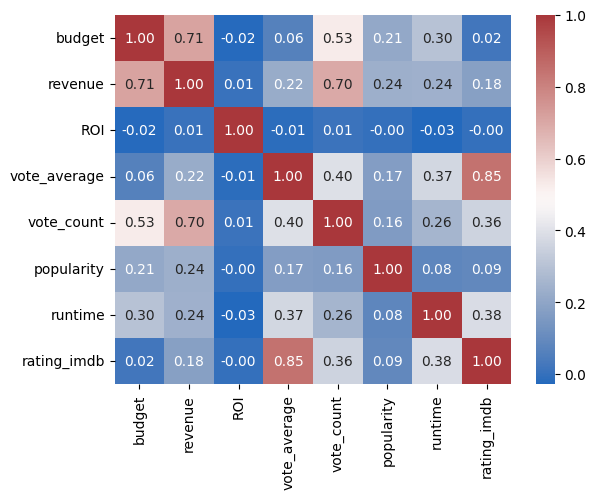

In [29]:
cor = ['budget', 'revenue', 'ROI', 'vote_average', 'vote_count', 'popularity', 'runtime', 'rating_imdb']
sns.heatmap(df[cor].corr(numeric_only=True), cmap="vlag", annot=True, fmt="0.2f");

про корреляцию код отсюда взял 1 в 1 https://github.com/hse-ds/iad-intro-ds/tree/master/2025/seminars/04_plots

у нас слишком много жанров в одной ячейке, поэтому будет сложно как-то оценивать, т.к. условно драма, криминал, триллер и драма, криминал будут 2 абсолютно разных жанра, оставим только первый жанр, самый важный

In [30]:
df['genres'] = df['genres'].astype(str).str.replace('\n', ',').str.split(',').str[0]

In [31]:
df.groupby("genres")["ROI"].mean().sort_values(ascending=False).head(10)

,ROI
genres,
Horror,60.880490
Documentary,41.346282
Music,4.951704
Mystery,4.854508
Comedy,4.408374
Animation,3.933195
Family,3.909273
Drama,3.784256
Adventure,3.147276


видим какие высокие показатели ROI у ужасов и документалок, про ужасы все ясно, мы видели эти выбросы своими глазами, посмотрим что там с документалками

In [32]:
documentaries = df[(df['genres'] == 'Documentary') & (df['ROI'] > 40)]
documentaries

,id,title_en,title_ru_x,release_date,genres,runtime,budget,revenue,vote_average,vote_count,...,imdb_id,cast,director,rating_filmru,rating_users,rating_imdb,url,ROI,log_budget,log_revenue
2908,42296,Catfish,Как я дружил в социальной сети,2010-09-17,Documentary,87,30000,3045943,6.818,551,...,tt1584016,"Nēv Schulman, Ariel Schulman, Angela Wesselman...",Ariel Schulman,6.0,6.3,7.1,https://www.film.ru/movies/kak-ya-druzhil-v-so...,101.531433,10.308986,14.929321
3460,1781,An Inconvenient Truth,Неудобная правда,2006-05-24,Documentary,100,1000000,46243000,6.977,969,...,tt0497116,"Al Gore, Billy West, Ronald Reagan, George W. ...",Davis Guggenheim,NaN,7.4,7.4,https://www.film.ru/movies/neudobnaya-pravda,46.243000,13.815512,17.649421
3727,9372,Super Size Me,Двойная порция,2004-01-17,Documentary,100,65000,28575078,6.726,1762,...,tt0390521,"Morgan Spurlock, Daryl Isaacs, Lisa Ganjhu, St...",Morgan Spurlock,NaN,6.9,7.2,https://www.film.ru/movies/dvoynaya-porciya,439.616585,11.082158,17.168046


вывод что нашли почему рои средний такой большой у документалок

далее посмотрим у фильмов на каких языках самый высокий показатель ROI

In [33]:
df.groupby("original_language")["ROI"].mean().sort_values(ascending=False).head(10)

,ROI
original_language,
th,73.800000
ar,16.244733
ja,13.163290
de,12.173210
ko,10.956181
en,9.489310
zh,8.864935
kn,6.954673
pt,6.105830


не разберешь какой язык поэтому переназовем

In [34]:
df['original_language'] = df['original_language'].replace({'en': 'Английский','fr': 'Французский','ja': 'Японский','zh': 'Китайский','no': 'Норвежский','it': 'Итальянский','cn': 'Кантонский','es': 'Испанский','th': 'Тайский','ml': 'Малаялам (Индия)','hi':' Хинди','te':'Телугу (Индия)', 'da': 'Датский','pl': 'Польский','fi': 'Финский','ko': 'Корейский','kn': 'Каннада (Индия)','sv': 'Шведский','is': 'Исландский','ru': 'Русский','ar': 'Арабский','tr': 'Турецкий','hu': 'Венгерский','id': 'Индонезийский','de': 'Немецкий','ro': 'Румынский','nl': 'Нидерландский','he': 'Иврит','pt': 'Португальский','bs': 'Боснийский','ta': 'Тамильский (Индия)'
})

In [35]:
df['original_language'].unique()

array(['Английский', 'Тамильский (Индия)', 'Французский', 'Японский',
       'Китайский', 'Норвежский', 'Итальянский', 'Кантонский',
       'Испанский', 'Тайский', 'Малаялам (Индия)', ' Хинди',
       'Телугу (Индия)', 'Датский', 'Польский', 'Финский', 'Корейский',
       'Каннада (Индия)', 'Шведский', 'Исландский', 'Русский', 'Арабский',
       'Турецкий', 'Венгерский', 'Индонезийский', 'Немецкий', 'Румынский',
       'Нидерландский', 'Иврит', 'Португальский', 'Боснийский'],
      dtype=object)

проверили что все ок с языками разобрались

дальше рассмотрим гипотезы

1)Среднебюджетные фильмы окупаются лучше, чем очень дорогие блокбастеры

разделим фильмы на несколько бюджетных сегментов

In [36]:
df['budget']=pd.qcut(df['budget'], 4, labels= ['0-25%', '25-50%', '50-75%', '75-100%'])

In [37]:
df.groupby('budget')['ROI'].median()

/tmp/ipykernel_64615/2888580364.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('budget')['ROI'].median()


,ROI
budget,
0-25%,2.437500
25-50%,1.866057
50-75%,2.030486
75-100%,2.482917


отдельно посмотрим долю фильмов которые окупились

In [38]:
profit = df.groupby('budget')['ROI'].apply(lambda x: (x > 1).mean())
profit*100

/tmp/ipykernel_64615/3012742458.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  profit = df.groupby('budget')['ROI'].apply(lambda x: (x > 1).mean())


,ROI
budget,
0-25%,67.713004
25-50%,68.933539
50-75%,73.787879
75-100%,84.862385


теперь покажем это на графике

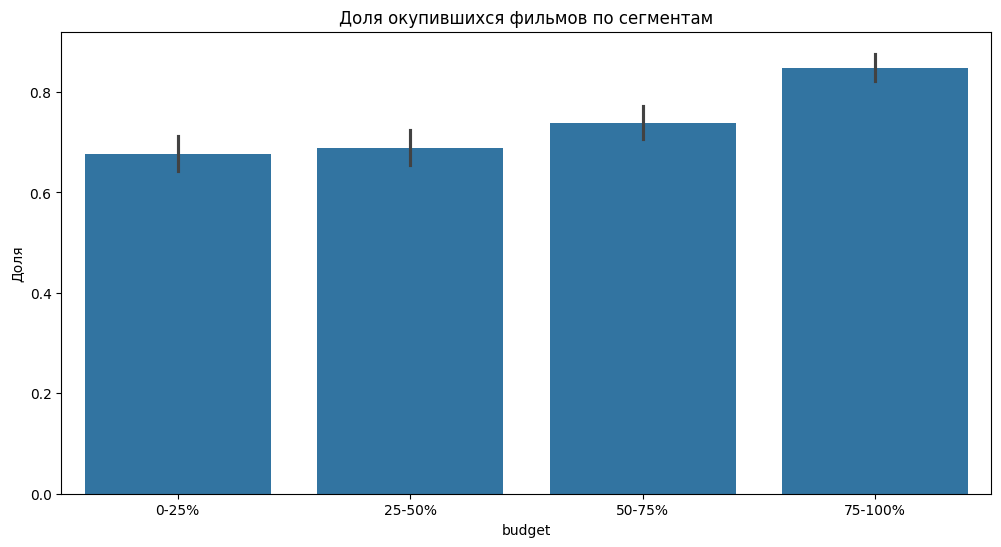

In [39]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='budget', y=df['ROI'] > 1)
plt.ylabel('Доля')
plt.title('Доля окупившихся фильмов по сегментам')
plt.show()

отвергаем гипотезу тк наглядно видим, что процент окупаемости растет по мере повышения бюджета

2)Существуют жанры, которые в среднем окупаются лучше других

In [40]:
table = df.groupby('genres')['ROI'].agg(['mean','median','count']).reset_index()

дальше добавим долю окупившихся фильмов

In [41]:
table['profitno'] = df.groupby('genres')['ROI'].apply(lambda x: (x > 1).mean()).values

дальше сортируем по медианному ROI чтобы увидеть самые стабильные жанры

In [42]:
table = table.sort_values(by='median', ascending=False)
table

,genres,mean,median,count,profitno
5,Documentary,41.346282,7.123919,17,0.823529
11,Music,4.951704,3.396121,11,0.909091
10,Horror,60.880490,3.040000,249,0.779116
2,Animation,3.933195,2.876333,136,0.816176
7,Family,3.909273,2.795042,64,0.875000
13,Romance,3.011421,2.600000,73,0.698630
3,Comedy,4.408374,2.515714,363,0.771350
12,Mystery,4.854508,2.466401,28,0.750000
8,Fantasy,2.798454,2.316952,77,0.857143
14,Science Fiction,3.031334,2.149827,93,0.731183


покажем на графике

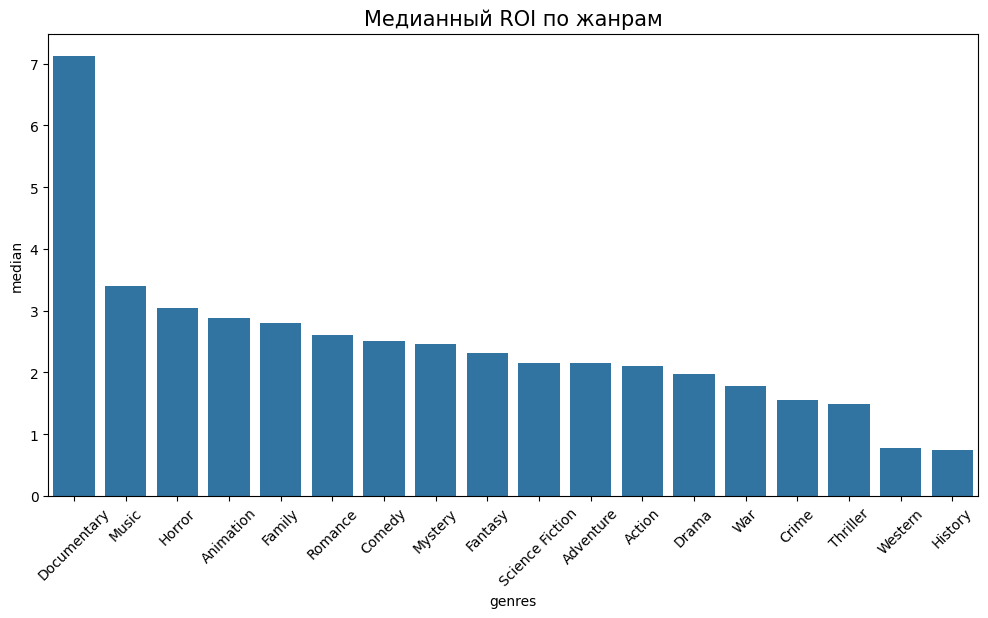

In [43]:
plt.figure(figsize=(12, 6))
sns.barplot(data=table, x='genres', y='median')
plt.title('Медианный ROI по жанрам', fontsize=15)
plt.xticks(rotation=45) #ДА мы знаем что такое ротейшн и сами это написали чтобы названия не сливались, кст в семинаре 2 было
plt.show()


да, существуют такие жанры, это хорошо видно на графике

3)Жанры с высокой окупаемостью не обязательно получают самые высокие оценки зрителей

чуть дополним таблицу из прошлого пункта

In [44]:
ratings = df.groupby('genres')['rating_imdb'].mean().reset_index()
table = table.merge(ratings, on='genres')

помотрим что получилось

In [45]:
table


,genres,mean,median,count,profitno,rating_imdb
0,Documentary,41.346282,7.123919,17,0.823529,7.052941
1,Music,4.951704,3.396121,11,0.909091,6.781818
2,Horror,60.880490,3.040000,249,0.779116,5.906855
3,Animation,3.933195,2.876333,136,0.816176,6.880882
4,Family,3.909273,2.795042,64,0.875000,6.334921
5,Romance,3.011421,2.600000,73,0.698630,6.569863
6,Comedy,4.408374,2.515714,363,0.771350,6.422314
7,Mystery,4.854508,2.466401,28,0.750000,6.628571
8,Fantasy,2.798454,2.316952,77,0.857143,6.352632
9,Science Fiction,3.031334,2.149827,93,0.731183,6.524731


отлично, посичтаем корреляцию

In [46]:
corr = table['rating_imdb'].corr(table['median'])
corr

np.float64(0.059347960090214626)

корреляция очень маленькая, значит можно утверждать, что высокие оценки не гарантируют большой выручки

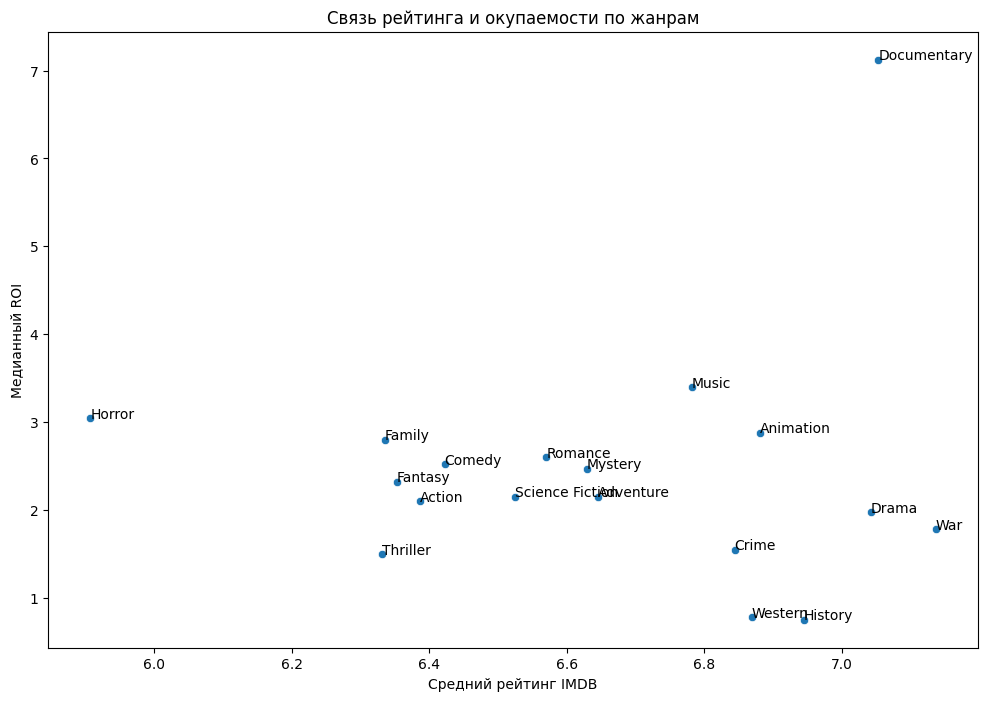

In [47]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=table, x='rating_imdb', y='median')
for i, row in table.iterrows():
    plt.text(row.rating_imdb, row['median'], row.genres)
plt.title('Связь рейтинга и окупаемости по жанрам')
plt.xlabel('Средний рейтинг IMDB')
plt.ylabel('Медианный ROI')
plt.show()


https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.iterrows.html
на всякий случай как я точки обзывал

гипотезу мы принимаем

4)Летние и зимние релизы в среднем прибыльнее, чем фильмы, вышедшие в межсезонье

разобьем даты по сезонам, сначала в дату переведем release_date

In [48]:
df['release_date'] = pd.to_datetime(df['release_date'])
seasons = {12:'зима', 1:'зима', 2:'зима', 3:'весна', 4:'весна', 5:'весна', 6:'лето', 7: 'лето', 8:'лето', 9:'осень', 10:'осень', 11: 'осень'}
df['season'] = df['release_date'].dt.month.map(seasons)

посмотрим как получилось

In [49]:
df.head(10)

,id,title_en,title_ru_x,release_date,genres,runtime,budget,revenue,vote_average,vote_count,...,cast,director,rating_filmru,rating_users,rating_imdb,url,ROI,log_budget,log_revenue,season
0,1327819,Hoppers,Прыгуны,2026-03-04,Animation,105,75-100%,334274009,7.586,425,...,"Piper Curda, Bobby Moynihan, Jon Hamm, Kathy N...",Daniel Chong,8.0,6.6,7.5,https://www.film.ru/movies/pryguny-0,2.228493,18.826146,19.627472,весна
1,1290821,Shelter,Убежище,2026-01-28,Action,107,50-75%,49305541,6.789,504,...,"Jason Statham, Bodhi Rae Breathnach, Michael S...",Ric Roman Waugh,6.0,6.9,6.2,https://www.film.ru/movies/ubezhishche-5,0.986111,17.727534,17.713547,зима
3,1171145,Crime 101,Ограбление в Лос-Анджелесе,2026-02-11,Crime,141,75-100%,72559167,7.100,576,...,"Chris Hemsworth, Mark Ruffalo, Halle Berry, Ba...",Bart Layton,6.0,6.2,6.9,https://www.film.ru/movies/ograblenie-v-los-an...,0.806213,18.315320,18.099913,зима
4,1226863,The Super Mario Galaxy Movie,Супер Марио: Галактическое кино,2026-04-01,Family,98,75-100%,429011034,6.938,333,...,"Chris Pratt, Charlie Day, Anya Taylor-Joy, Jac...",Aaron Horvath,NaN,6.9,6.5,https://www.film.ru/movies/super-mario-galakti...,3.900100,18.515991,19.876993,весна
5,1297842,GOAT,Goat: Мечтай по-крупному,2026-02-11,Animation,100,75-100%,185251324,7.900,353,...,"Caleb McLaughlin, Gabrielle Union, Stephen Cur...",Tyree Dillihay,NaN,7.0,6.7,https://www.film.ru/movies/goat-mechtay-po-kru...,2.058348,18.315320,19.037224,зима
6,840464,Greenland 2: Migration,Гренландия 2: Миграция,2026-01-07,Adventure,98,75-100%,44579387,6.490,834,...,"Gerard Butler, Morena Baccarin, Roman Griffin ...",Ric Roman Waugh,6.0,6.0,5.2,https://www.film.ru/movies/grenlandiya-2-migra...,0.495327,18.315320,17.612782,зима
7,687163,Project Hail Mary,Проект «Аве Мария»,2026-03-15,Science Fiction,157,75-100%,429965411,8.190,1195,...,"Ryan Gosling, James Ortiz, Sandra Hüller, Lion...",Phil Lord,8.0,7.0,8.4,https://www.film.ru/movies/proekt-konec-sveta,2.149827,19.113828,19.879215,весна
10,1159559,Scream 7,Крик 7,2026-02-25,Horror,114,50-75%,209505101,6.030,697,...,"Neve Campbell, Courteney Cox, Isabel May, Jasm...",Kevin Williamson,7.0,6.4,5.6,https://www.film.ru/movies/krik-7-0,4.655669,17.622173,19.160259,зима
12,1193501,Whistle,Свист,2026-01-20,Horror,100,0-25%,2568027,5.969,226,...,"Dafne Keen, Sophie Nélisse, Sky Yang, Jhaleil ...",Corin Hardy,3.0,5.8,5.2,https://www.film.ru/movies/svist-1,1.284013,14.508658,14.758649,зима
13,1198994,Send Help,Пришлите помощь,2026-01-22,Horror,113,50-75%,94037307,7.054,900,...,"Rachel McAdams, Dylan O'Brien, Edyll Ismail, D...",Sam Raimi,8.0,5.9,6.9,https://www.film.ru/movies/na-pomoshch,2.350933,17.504390,18.359202,зима


https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.map.html тоже на всякий случай про map

посмотрим на статистику по сезонам

In [50]:
seasons = df.groupby('season')[['revenue', 'ROI']].agg(['mean', 'median', 'count'])
seasons


revenue                          ROI                
                mean      median count       mean    median count
season                                                           
весна   1.719379e+08  65663998.5   570   3.743961  2.129173   570
зима    1.401739e+08  65754228.0   625   4.569627  2.342969   625
лето    1.762971e+08  82966152.0   625   4.968826  2.454281   625
осень   1.164908e+08  40030054.0   810  19.703767  1.830553   810

можем заметить, что у лета самые высокие медианная выручка и медианный ROI
осень очень аномальна, средний ROI огромный, медиана самая низкая, можно предположить, что эти выбросы связаны с выходом  какого-то сверхбюджетного хита, он задрал среднее значение

/tmp/ipykernel_64615/1651741653.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='season', y='ROI', palette='coolwarm', showfliers=False)


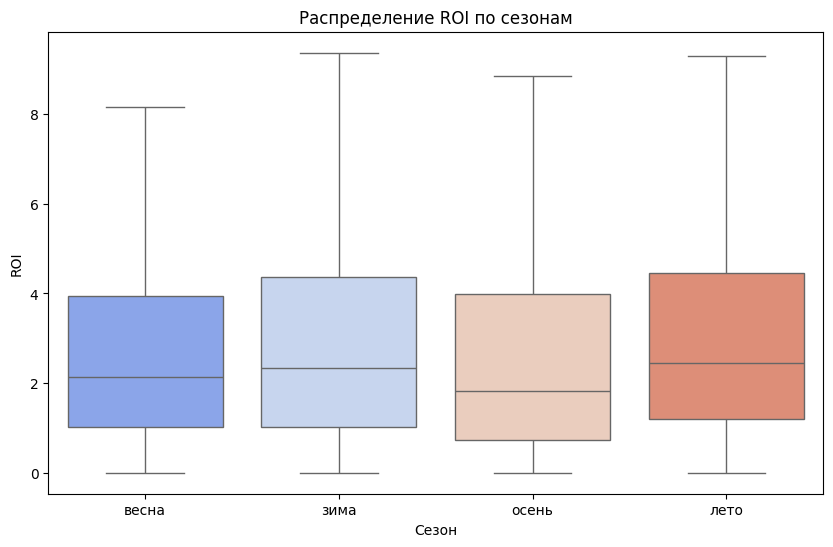

In [51]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='season', y='ROI', palette='coolwarm', showfliers=False)
plt.title('Распределение ROI по сезонам')
plt.ylabel('ROI')
plt.xlabel('Сезон')
plt.show()


https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.boxplot.html тут боксплотовские фишки брал, без palette='coolwarm', showfliers=False получалось слишком ужасно

на графике хорошо видно что у осени самый низкий уровень медианы, а лето и зима явно доминируют